In [49]:
import warnings

warnings.filterwarnings("ignore")

from itertools import groupby

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import spearmanr
from scipy.stats import shapiro

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import textwrap

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

### 1. Получить файл варианта с данными

In [50]:
DATA_PATH = "Вар_42_Б24-215_Гаганидзе_Лаба2_студент.xlsx"
#DATA_PATH = "Вар_46_Б24-215_Кузьмина_Лаба2_студент.xlsx"
df_raw = pd.read_excel(DATA_PATH)
print(f"Размер: {df_raw.shape}")
# print(f"Колонки:\n {"\n".join(list(df_raw.columns))}")
display(df_raw)

Размер: (2500, 26)


,ID,"Среднегодовой доход, тыс. $","Объем потребленного алкоголя в год, л.",Количество членов семьи,Количество лет образования,"Доля от дохода семьи которая тратится на продовольствие, %",Коэффициент Джини сообщества,"Издержки сообщества на окружающую среду, млн. $","Охват беспроводной связи в сообществе, %","Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек",Волатильность потребительских цен в сообществе,Сфера занятости,Оценка благополучия,Оценка социальной поддержки,Ожидаемая продолжительность здоровой жизни,Свобода граждан самостоятельно принимать жизненно важные решения,Индекс Щедрости,Индекс отношения к коррупции,Оценка риска безработицы,Индекс кредитного оптимизма,Индекс страха социальных конфликтов,Индекс семьи,Индекс продовольственной безопасности,Чувство технологического прогресса,Чувство неравенства доходов в обществе,Ощущаемое счастье
0,1,84.091,13.02,6,8,49.0,0.472727,154.49,0.329,15.74,3.50,Корпоративный сектор,67.0,52.0,50.0,59.0,53.0,40.0,51.0,43.0,78.0,18.0,49.0,40.0,43.0,Suffering
1,2,301.312,0.00,3,13,30.0,0.183591,389.61,0.669,4.58,7.00,Неформальная занятость,76.0,70.0,36.0,47.0,71.0,35.0,67.0,57.0,46.0,28.0,70.0,62.0,51.0,Doing well
2,3,275.853,7.46,5,11,42.1,0.383192,284.57,0.658,21.93,5.31,Корпоративный сектор,48.0,72.0,24.0,55.0,59.0,29.0,36.0,46.0,25.0,26.0,48.0,50.0,51.0,Coping
3,4,275.425,0.00,4,17,30.1,0.263366,284.71,0.807,6.37,4.22,Государственная служба,43.0,87.0,59.0,45.0,70.0,45.0,43.0,72.0,40.0,31.0,82.0,69.0,61.0,Doing well
4,5,228.560,8.71,3,13,33.7,0.183591,389.61,0.669,4.58,7.00,Государственная служба,32.0,67.0,48.0,55.0,52.0,53.0,38.0,55.0,46.0,28.0,70.0,51.0,38.0,Coping
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,71.486,16.09,4,9,57.5,0.472727,154.49,0.329,15.74,3.50,Неформальная занятость,84.0,51.0,53.0,30.0,37.0,80.0,68.0,22.0,8.0,23.0,52.0,32.0,46.0,Depressed
2496,2497,242.672,1.06,4,12,30.9,0.263366,284.71,0.807,6.37,4.22,Самозанятый,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Неизвестно
2497,2498,60.765,0.00,6,13,57.9,0.834747,0.00,0.359,11.92,0.00,Неформальная занятость,40.0,85.0,38.0,65.0,42.0,64.0,61.0,67.0,33.0,29.0,62.0,56.0,39.0,Thriving
2498,2499,316.403,6.79,4,15,32.8,0.481202,143.32,0.911,0.00,3.43,МСП,80.0,83.0,75.0,70.0,22.0,63.0,49.0,63.0,66.0,21.0,98.0,62.0,46.0,Doing well


In [51]:
df_work = df_raw.drop(columns=["ID"])

grouped_data = [
    (is_numeric, df_work[list(g)])
    for is_numeric, g in groupby(
        df_work.columns, key=lambda c: df_work[c].dtype != "str"
    )
]

for i, (is_numeric, df_group) in enumerate(grouped_data, 1):
    group_type = "Численные" if is_numeric else "Строковые"
    print(f"--- Группа {i} ({group_type}) ---")
    print(*df_group.columns, sep="\n", end="\n\n")

--- Группа 1 (Численные) ---
Среднегодовой доход, тыс. $
Объем потребленного алкоголя в год, л.
Количество членов семьи
Количество лет образования
Доля от дохода семьи которая тратится на продовольствие, %
Коэффициент Джини сообщества
Издержки сообщества на окружающую среду, млн. $
Охват беспроводной связи в сообществе, %
Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек
Волатильность потребительских цен в сообществе

--- Группа 2 (Строковые) ---
Сфера занятости

--- Группа 3 (Численные) ---
Оценка благополучия
Оценка социальной поддержки
Ожидаемая продолжительность здоровой жизни
Свобода граждан самостоятельно принимать жизненно важные решения
Индекс Щедрости
Индекс отношения к коррупции
Оценка риска безработицы
Индекс кредитного оптимизма
Индекс страха социальных конфликтов
Индекс семьи
Индекс продовольственной безопасности
Чувство технологического прогресса
Чувство неравенства доходов в обществе

--- Группа 4 (Строковые) ---
Ощущаемое счастье



### 2. Открыть набор данных и выделить группы признаков: причины, состояния, целевая переменная

In [52]:
# Полный ординальный порядок меток (от худшего к лучшему).
# 'Strugglng' — опечатка в исходных данных, оставляем как есть.
CANTRIL_ORDER = [
    "Hopeless",
    "Depressed",
    "Suffering",
    "Strugglng",
    "Coping",
    "Just ok",
    "Doing well",
    "Blooming",
    "Thriving",
    "Prospering",
]

CANTRIL_COL = df_raw.columns[-1] # "Ощущаемое счастье"
MARKER_UNKNOWN = "Неизвестно" # метка «неизвестно» в этой колонке

ALL_CAUSE, STATE_FEATURES = [
    list(g.columns) for is_numeric, g in grouped_data if is_numeric
]


CAT_FEATURES = [
    col for is_numeric, g in grouped_data
    if not is_numeric and CANTRIL_COL not in g.columns
    for col in g.columns
]

SIGNIFICANCE_THRESHOLD = 0.1  # порог |ρ| для отбора признаков состояния
VIF_THRESHOLD = 5.0
PVALUE_THRESHOLD = 0.05
RHO_THRESHOLD = 0.2
R2_THRESHOLD = 0.45

### 3. Выделить наблюдения с известным и неизвестным значением счастья

In [53]:
is_unknown = (df_raw[CANTRIL_COL].str.strip() == MARKER_UNKNOWN) | \
    (df_raw[CANTRIL_COL].isna())

df_known = df_raw[~is_unknown].copy()
df_unknown = df_raw[is_unknown].copy()

print(f"Известных записей:   {len(df_known)}")
print(f"Неизвестных записей: {len(df_unknown)}")

actual_classes = [
    c for c in CANTRIL_ORDER if c in df_known[CANTRIL_COL].unique()
]
df_known["rank"] = pd.Categorical(
    df_known[CANTRIL_COL], categories=actual_classes, ordered=True
).codes

print("Кодировка классов:")
for rank, cls in enumerate(actual_classes):
    print(f"  {rank:>2}: {cls}")

Известных записей:   1900
Неизвестных записей: 600
Кодировка классов:
   0: Hopeless
   1: Depressed
   2: Suffering
   3: Strugglng
   4: Coping
   5: Just ok
   6: Doing well
   7: Blooming
   8: Thriving
   9: Prospering


### 4. Провести первичный анализ данных (описательные статистики, визуализация, проверка пропусков)


Пропусков в неизвестных данных:
Оценка благополучия                                                 600
Оценка социальной поддержки                                         600
Ожидаемая продолжительность здоровой жизни                          600
Свобода граждан самостоятельно принимать жизненно важные решения    600
Индекс Щедрости                                                     600
Индекс отношения к коррупции                                        600
Оценка риска безработицы                                            600
Индекс кредитного оптимизма                                         600
Индекс страха социальных конфликтов                                 600
Индекс семьи                                                        600
Индекс продовольственной безопасности                               600
Чувство технологического прогресса                                  600
Чувство неравенства доходов в обществе                              600
dtype: int64


Описательные чис

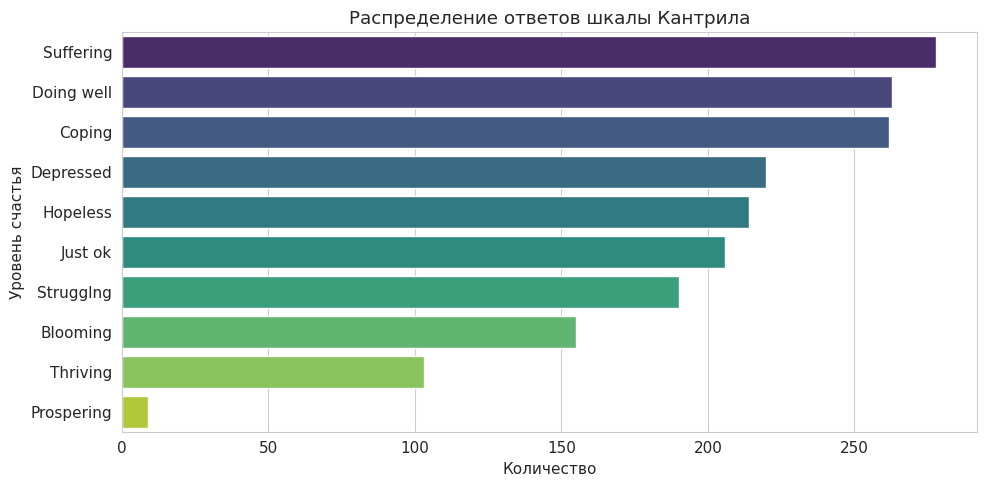

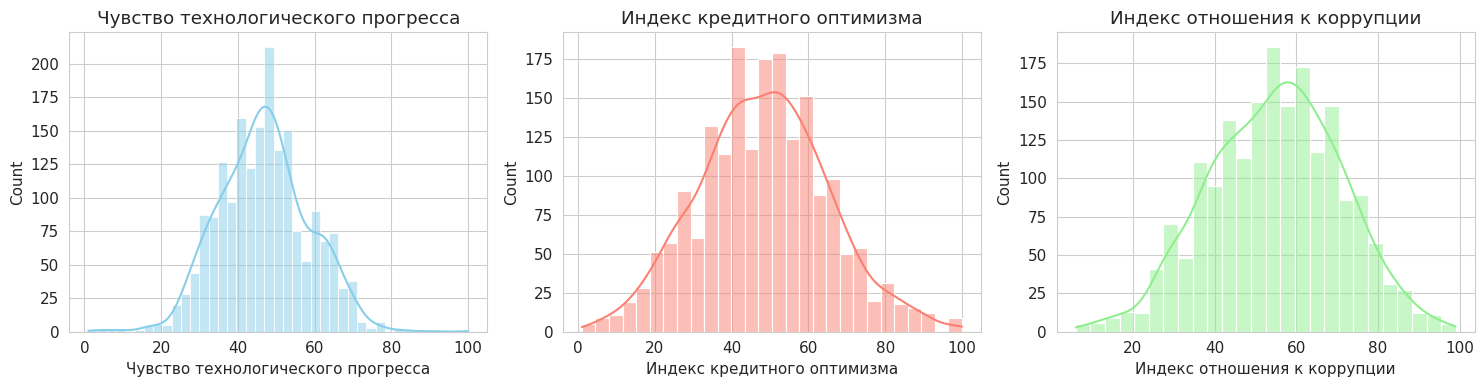

In [54]:
# 1. Проверка пропусков
print("\nПропусков в неизвестных данных:")
missing_info = df_raw.isna().sum()
missing_info = missing_info[missing_info > 0]
if missing_info.empty:
    print("Пропусков нет!\n")
else:
    print(missing_info)
    print("\n")

# 2. Описательные статистики числовых признаков
print("Описательные числовые статистики:")
#display(df_raw.describe().round(2).T)

# 3. Визуализация распределения целевой переменной
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_known,
    y=CANTRIL_COL,
    order=df_known[CANTRIL_COL].value_counts().index,
    palette="viridis",
)
plt.title("Распределение ответов шкалы Кантрила")
plt.xlabel("Количество")
plt.ylabel("Уровень счастья")
plt.tight_layout()
plt.show()

# 5. Визуализация некоторых числовых признаков (гистограммы состояния)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(
    df_raw["Чувство технологического прогресса"],
    kde=True,
    ax=axes[0],
    color="skyblue",
)
axes[0].set_title("Чувство технологического прогресса")

sns.histplot(
    df_raw["Индекс кредитного оптимизма"],
    kde=True,
    ax=axes[1],
    color="salmon"
)
axes[1].set_title("Индекс кредитного оптимизма")

sns.histplot(
    df_raw["Индекс отношения к коррупции"],
    kde=True,
    ax=axes[2],
    color="lightgreen",
)
axes[2].set_title("Индекс отношения к коррупции")

plt.tight_layout()
plt.show()

### 5. Исследовать влияние признаков причины на признаки состояния (корреляционный анализ, линейные регрессии)

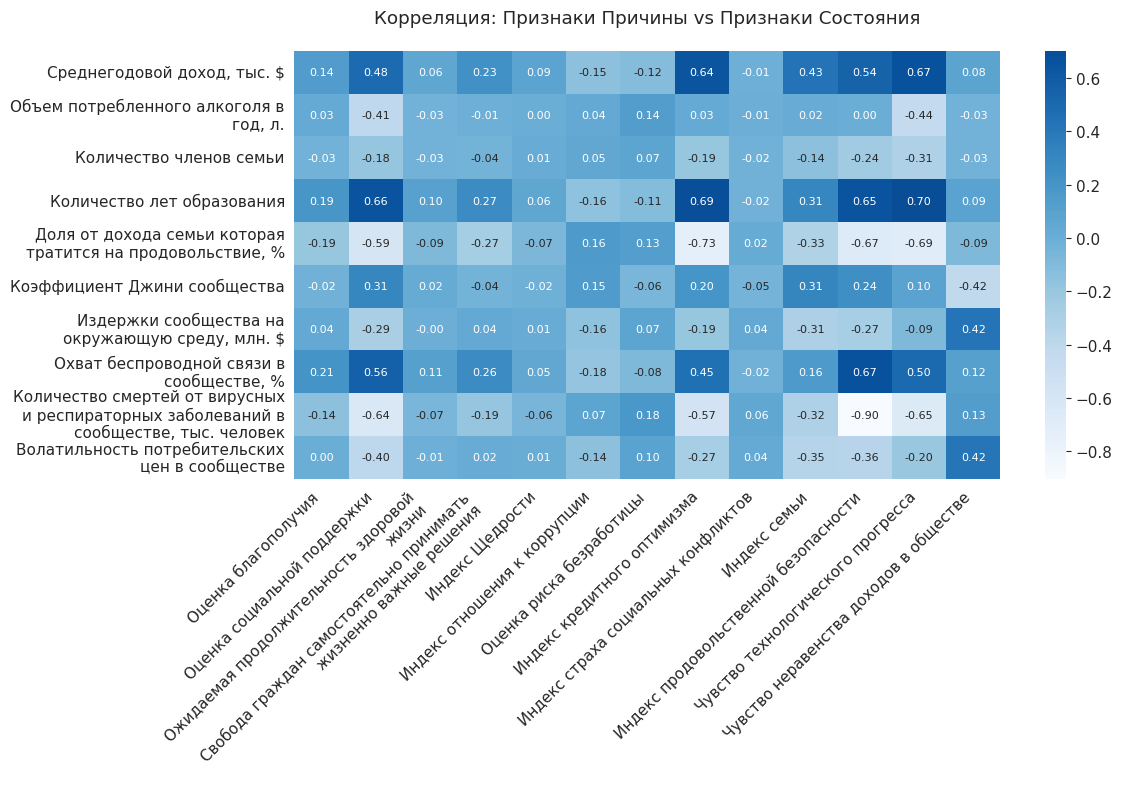

In [55]:
plt.figure(figsize=(12, 8))

cause_state_corr = (
    df_known[ALL_CAUSE + STATE_FEATURES]
    .corr(method="spearman")
    .loc[ALL_CAUSE, STATE_FEATURES]
)

wrapped_y_labels = [textwrap.fill(label, 30) for label in cause_state_corr.index]
wrapped_x_labels = [textwrap.fill(label, 40) for label in cause_state_corr.columns]

sns.heatmap(
    cause_state_corr,
    cmap="Blues",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    yticklabels=wrapped_y_labels,
    xticklabels=wrapped_x_labels,
)
plt.title("Корреляция: Признаки Причины vs Признаки Состояния", pad=20)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [56]:
# 1. ЕДИНЫЙ СПЛИТ ДАННЫХ ДЛЯ ВСЕЙ ЛАБОРАТОРНОЙ 
# (Перенесли сюда из шага 7, чтобы избежать data leakage и двойных разбиений)
df_train, df_test = train_test_split(
    df_known,
    test_size=0.25,
    random_state=42,
    stratify=df_known["rank"]
)

# 2. Функция VIF только для тренировочных данных
def compute_vif_train(X_df):
    X_const = sm.add_constant(X_df.dropna())
    vif_vals = [variance_inflation_factor(X_const.values, i) for i in range(1, X_const.shape[1])]
    return pd.DataFrame({"Признак": X_df.columns, "VIF": vif_vals}).sort_values("VIF", ascending=False)

# Считаем VIF ТОЛЬКО по Причинам на train
current_cols = list(ALL_CAUSE)
while True:
    vif_res = compute_vif_train(df_train[current_cols])
    worst = vif_res.iloc[0]
    if worst["VIF"] <= VIF_THRESHOLD:
        break
    current_cols.remove(worst["Признак"])

print("Итоговые колонки после VIF:", *current_cols, sep="\n", end="\n\n")

# Тренируем отдельную модель для каждого "Состояния" на основе отобранных "Причин"
# (полный датасет df_known, это описательная часть шага 5)
ols_state_models_full = {}

for state_col in STATE_FEATURES:
    # Используем только те причины, которые прошли VIF (current_cols)
    valid_data = df_train.dropna(subset=[state_col] + current_cols) # df_known?
    if valid_data.empty:
        continue

    y_target = valid_data[state_col]
    X_features = sm.add_constant(
        valid_data[current_cols]
    )  # Добавляем константу

    # ТРЕНИРУЕМ МОДЕЛЬ
    model = sm.OLS(y_target, X_features).fit()
    ols_state_models_full[state_col] = model

    t_stats = model.tvalues.drop("const").abs()

    print(f"\nВлияющие причины на состояние '{state_col}':")

    std_y = y_target.std()
    std_X = X_features.std()
    BETA_THRESHOLD = 0.1  
    
    for cause_name, t_val in t_stats.items():
        coef = model.params[cause_name]
        p_val = model.pvalues[cause_name]

        beta_coef = coef * (std_X[cause_name] / std_y)

        if p_val < PVALUE_THRESHOLD and abs(beta_coef) >= BETA_THRESHOLD:
            print(f"\t• {cause_name}")
            print(
                f"\tВлияние: {'прямое' if coef > 0 else 'обратное'} (p={p_val:.3f}, Beta={beta_coef:+.3f})"
            )

Итоговые колонки после VIF:
Среднегодовой доход, тыс. $
Объем потребленного алкоголя в год, л.
Количество членов семьи
Количество лет образования
Доля от дохода семьи которая тратится на продовольствие, %
Коэффициент Джини сообщества
Охват беспроводной связи в сообществе, %
Количество смертей от вирусных и респираторных заболеваний в сообществе, тыс. человек


Влияющие причины на состояние 'Оценка благополучия':
	• Охват беспроводной связи в сообществе, %
	Влияние: прямое (p=0.005, Beta=+0.112)

Влияющие причины на состояние 'Оценка социальной поддержки':
	• Объем потребленного алкоголя в год, л.
	Влияние: обратное (p=0.000, Beta=-0.526)
	• Количество лет образования
	Влияние: прямое (p=0.000, Beta=+0.416)
	• Коэффициент Джини сообщества
	Влияние: прямое (p=0.000, Beta=+0.386)
	• Охват беспроводной связи в сообществе, %
	Влияние: прямое (p=0.000, Beta=+0.333)

Влияющие причины на состояние 'Ожидаемая продолжительность здоровой жизни':
	• Количество смертей от вирусных и респираторных з

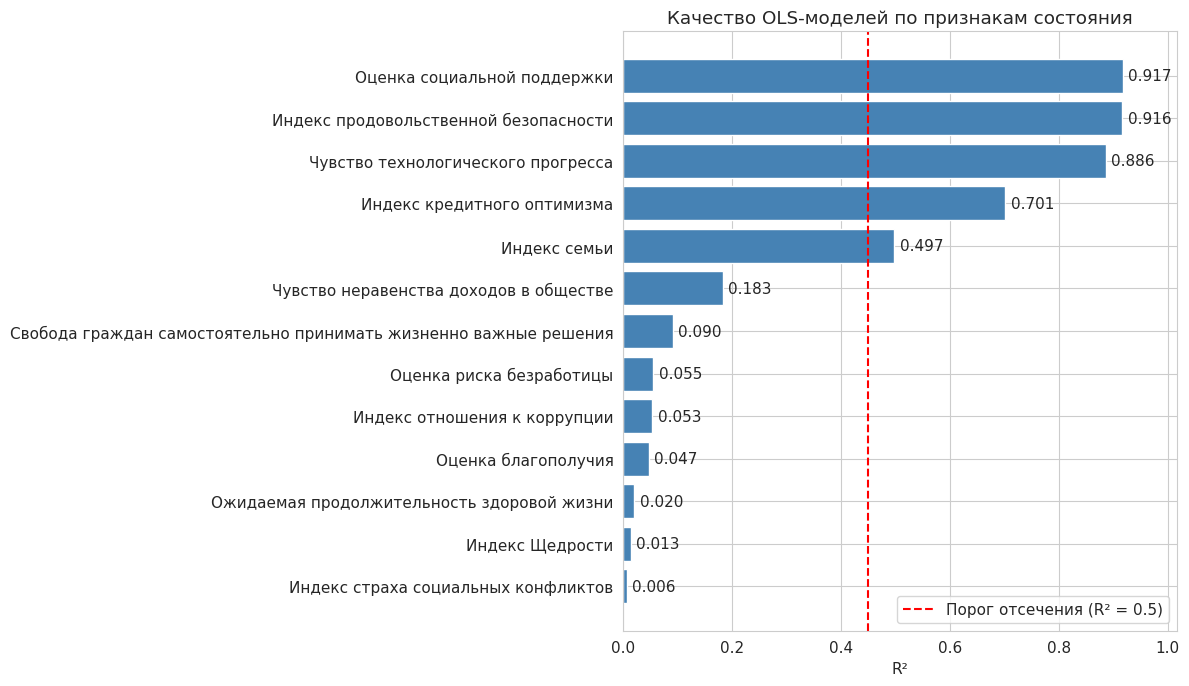

In [57]:
actual_states = [s for s in STATE_FEATURES if s in ols_state_models_full]

rsquared_df = pd.DataFrame(
    {
        "Признак состояния": actual_states,
        "R²": [ols_state_models_full[s].rsquared for s in actual_states],
    }
).sort_values("R²", ascending=True)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    rsquared_df["Признак состояния"], rsquared_df["R²"], color="steelblue"
)
plt.xlabel("R²")
plt.title("Качество OLS-моделей по признакам состояния")

for bar, val in zip(bars, rsquared_df["R²"]):
    plt.text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
    )
plt.axvline(x=R2_THRESHOLD, color='red', linestyle='--', label='Порог отсечения (R² = 0.5)')
plt.legend(loc='lower right')
plt.xlim(0, max(rsquared_df["R²"]) + 0.1)
plt.tight_layout()
plt.show()

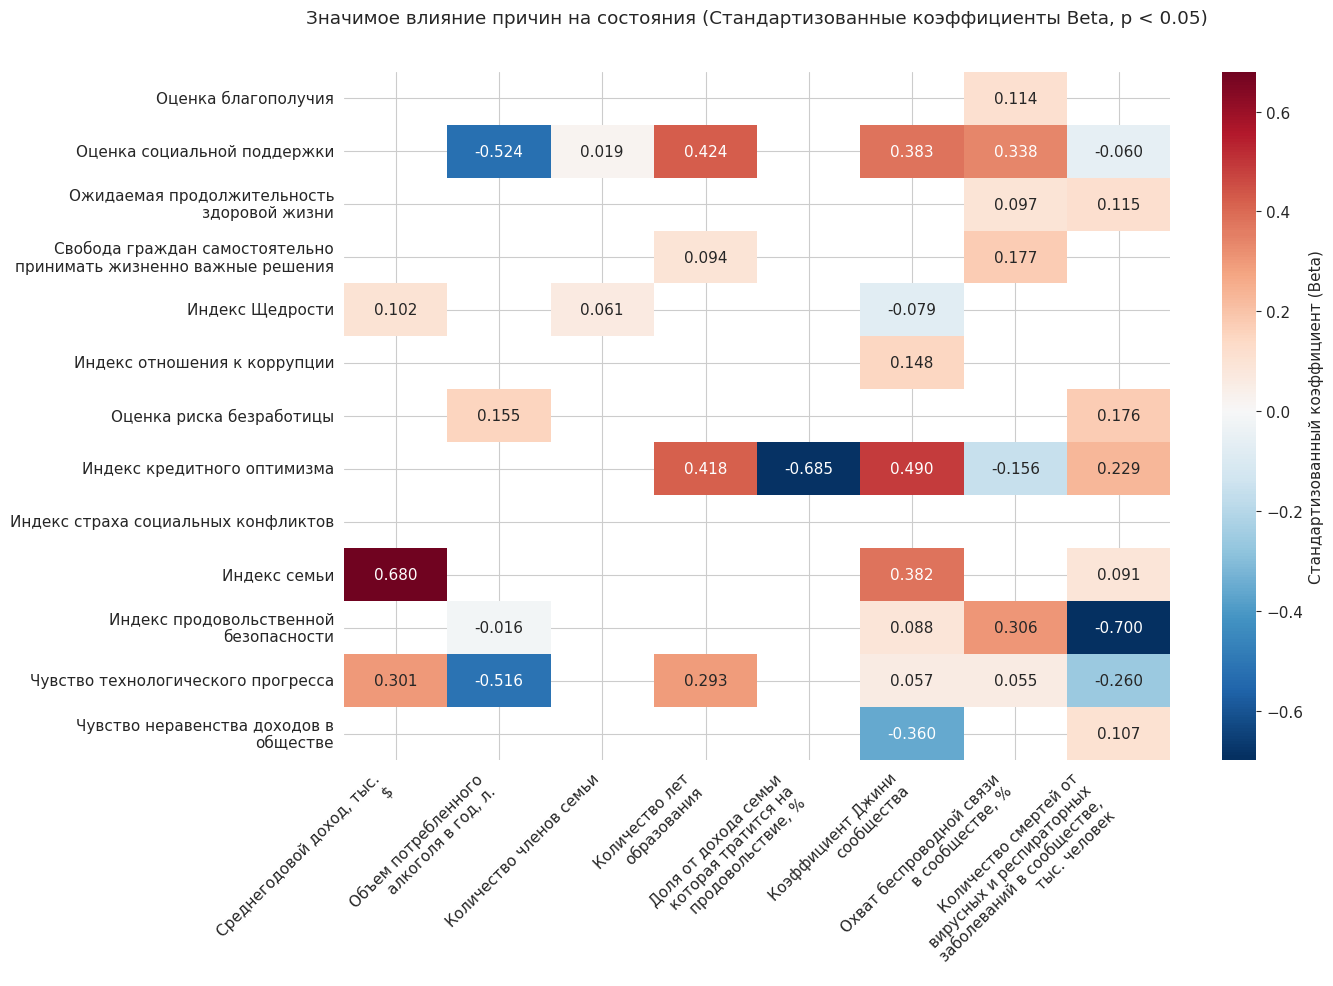

In [58]:
p_val_matrix = pd.DataFrame()
coef_matrix = pd.DataFrame()

for state, model in ols_state_models_full.items():
    p_val_matrix[state] = model.pvalues.drop("const")

    # Считаем СТАНДАРТИЗОВАННЫЕ коэффициенты (Beta)
    valid_data = df_known.dropna(subset=[state] + current_cols)
    std_x = valid_data[current_cols].std()
    std_y = valid_data[state].std()

    std_coefs = model.params.drop("const") * (std_x / std_y)
    coef_matrix[state] = std_coefs

# Транспонируем (состояния - строки, причины - столбцы)
p_val_matrix = p_val_matrix.T
coef_matrix = coef_matrix.T

# Создаем матрицу-маску: оставляем коэффициенты ТОЛЬКО там, где p < 0.05
significant_coefs = coef_matrix.mask(p_val_matrix >= PVALUE_THRESHOLD)

plt.figure(figsize=(14, 10))
# cmap='RdBu_r' - красные (положительные), синие (отрицательные)
sns.heatmap(
    significant_coefs,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    xticklabels=[textwrap.fill(c, 25) for c in significant_coefs.columns],
    yticklabels=[textwrap.fill(c, 35) for c in significant_coefs.index],
    cbar_kws={"label": "Стандартизованный коэффициент (Beta)"},
)

plt.title(
    "Значимое влияние причин на состояния (Стандартизованные коэффициенты Beta, p < 0.05)\n",
    pad=20,
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Непонятные кластеры

### 6. Проверить влияние категориальных факторов на признаки состояния (например, сфера занятости; ANOVA, тест Манна—Уитни)

In [59]:
print(df_known[CAT_FEATURES[0]].dropna().unique())

<StringArray>
[  'Корпоративный сектор', 'Неформальная занятость', 'Государственная служба',
                    'МСП',            'Самозанятый',            'Безработный']
Length: 6, dtype: str


In [60]:
for cat_feature in CAT_FEATURES:
    groups = df_known[cat_feature].dropna().unique()
    print(
        f"Влияние категориального фактора '{cat_feature}' на признаки состояния\n"
    )

    for state_col in STATE_FEATURES:
        # Собираем значения признака состояния для каждой отдельной категории
        group_data = [
            df_known[df_known[cat_feature] == g][state_col].dropna()
            for g in groups
        ]

        # Отфильтруем группы, в которых слишком мало наблюдений (например, < 5)
        group_data = [d for d in group_data if len(d) >= 5]

        if len(group_data) == 2:
            # Если ровно 2 группы (например, Мужчины / Женщины) -> Тест Манна-Уитни
            stat, p_val = stats.mannwhitneyu(
                group_data[0], group_data[1], alternative="two-sided"
            )
            test_name = "Манна-Уитни"

        elif len(group_data) > 2:
            # Если 3 и более групп (например, разные сферы занятости) -> Краскела-Уоллиса (непараметрический ANOVA)
            # Используем его вместо классического f_oneway ANOVA, так как он не требует нормальности распределения
            stat, p_val = stats.kruskal(*group_data)
            test_name = "Краскела-Уоллиса (ANOVA)"
        else:
            continue

        if p_val < PVALUE_THRESHOLD:
            print(f"Признак: {state_col}")
            print(f"  Тест: {test_name} | p-value = {p_val} \n")

Влияние категориального фактора 'Сфера занятости' на признаки состояния

Признак: Индекс Щедрости
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 0.018709874403257363 

Признак: Индекс отношения к коррупции
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 0.00026363468716299524 

Признак: Оценка риска безработицы
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 0.018109789397910334 

Признак: Индекс кредитного оптимизма
  Тест: Краскела-Уоллиса (ANOVA) | p-value = 3.1516656554223026e-31 



### 7. Отобрать значимые и интерпретируемые признаки состояния

In [61]:
# 1. СПЛИТ ДАННЫХ (Уже сделан в шаге 5 в едином месте)
# Сразу выделяем целевые метки для ML-моделей
y_train = df_train["rank"]
y_test = df_test["rank"]

print(f"Размер обучающей выборки (train): {df_train.shape[0]} записей")
print(f"Размер тестовой выборки (test): {df_test.shape[0]} записей\n")

# 2. ОТБОР ПРИЗНАКОВ (Только на Train, чтобы избежать data leakage)

corr_results = []
for col in STATE_FEATURES:
    valid = df_train[[col, "rank"]].dropna()
    #if len(valid) < 10:
    #    continue
    rho, pval = spearmanr(valid[col], valid["rank"])
    corr_results.append(
        {"Признак состояния": col, "Spearman": rho, "p-value": pval}
    )

corr_df = pd.DataFrame(corr_results).sort_values(
    "Spearman", key=abs, ascending=False
)
print("Все корреляции:")
print(corr_df.to_string(index=False))

# Берём: 1) статистически значимые + 2) с адекватной силой связи
selected_state = corr_df[
    (corr_df["p-value"] < PVALUE_THRESHOLD)
    & (corr_df["Spearman"].abs() >= RHO_THRESHOLD)
]["Признак состояния"].tolist()

print(
    f"\nОтобраны признаки состояния (p < {PVALUE_THRESHOLD} и |ρ| >= {RHO_THRESHOLD}): {len(selected_state)} шт."
)
for f in selected_state:
    row = corr_df[corr_df["Признак состояния"] == f].iloc[0]
    print(f"  ρ={row['Spearman']:+.3f}  p={row['p-value']:.2e}  {f}")

Размер обучающей выборки (train): 1425 записей
Размер тестовой выборки (test): 475 записей

Все корреляции:
                                               Признак состояния  Spearman       p-value
                                     Оценка социальной поддержки  0.759619 3.721995e-268
                              Чувство технологического прогресса  0.709453 1.698236e-218
                                     Индекс кредитного оптимизма  0.686501 3.641036e-199
                           Индекс продовольственной безопасности  0.602767 1.072897e-141
                                                    Индекс семьи  0.544244 1.116899e-110
                          Чувство неравенства доходов в обществе -0.371853  5.861813e-48
Свобода граждан самостоятельно принимать жизненно важные решения  0.175692  2.415426e-11
                                        Оценка риска безработицы -0.158455  1.806470e-09
                                             Оценка благополучия  0.147671  2.139779e-08
  

Видим, что каждый из 6 признаков значимый и интерпретируемый (есть логическая связь с целевой переменной).

Оценка социальной поддержки
Чувство технологического прогресса
Индекс кредитного оптимизма
Индекс продовольственной безопасности
Индекс семьи
Чувство неравенства доходов в обществе


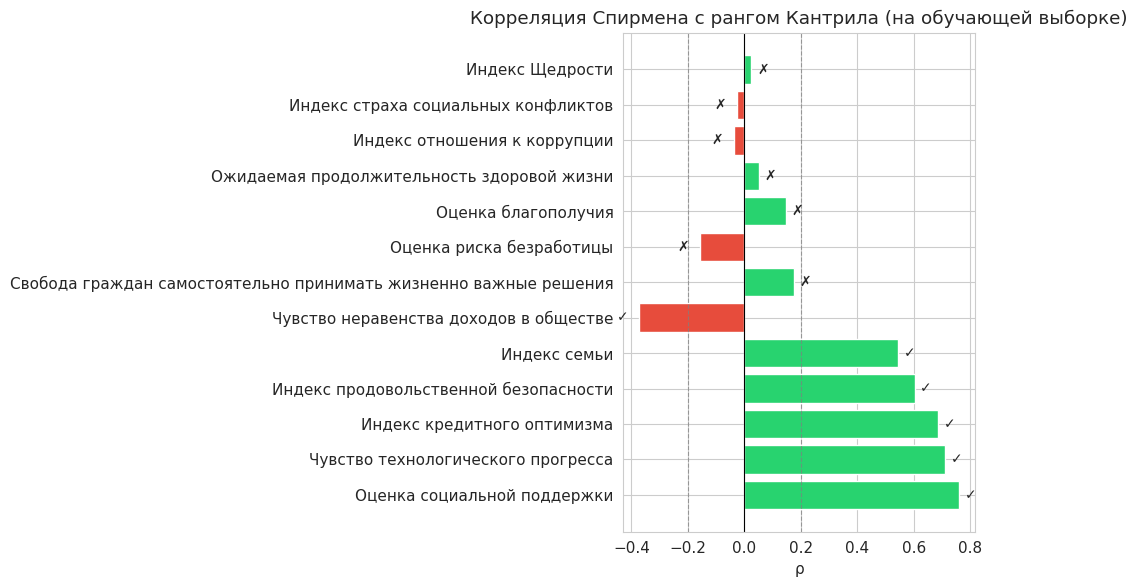

In [62]:
# 3. ВИЗУАЛИЗАЦИЯ
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#28d36f" if r > 0 else "#e74c3c" for r in corr_df["Spearman"]]
ax.barh(corr_df["Признак состояния"], corr_df["Spearman"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

# Рисуем пороги отсечения (пунктиром)
ax.axvline(
    RHO_THRESHOLD, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
)
ax.axvline(
    -RHO_THRESHOLD, color="gray", linestyle="--", linewidth=0.8, alpha=0.7
)

for i, (_, row) in enumerate(corr_df.iterrows()):
    is_selected = (row["p-value"] < PVALUE_THRESHOLD) and (
        abs(row["Spearman"]) >= RHO_THRESHOLD
    )
    marker = "✓" if is_selected else "✗"
    if is_selected:
        print(row["Признак состояния"])
    x = row["Spearman"]
    ax.text(
        x + (0.02 if x >= 0 else -0.08), i, marker, va="center", fontsize=10
    )

ax.set_title("Корреляция Спирмена с рангом Кантрила (на обучающей выборке)")
ax.set_xlabel("ρ")
plt.tight_layout()
plt.show()


### 9. Построить модели прогноза признаков состояния по признакам причины

ПОСТРОЕНИЕ OLS ДЛЯ ОТОБРАННЫХ ПРИЗНАКОВ СОСТОЯНИЯ

Признак 'Оценка социальной поддержки'
  R²:               0.906
  Durbin-Watson:    1.997
  Бреуш-Паган p:    0.0237 HC3
  SE:               HC3 (робастные)
  Шапиро-Уилк p:    0.8279 → нормальны


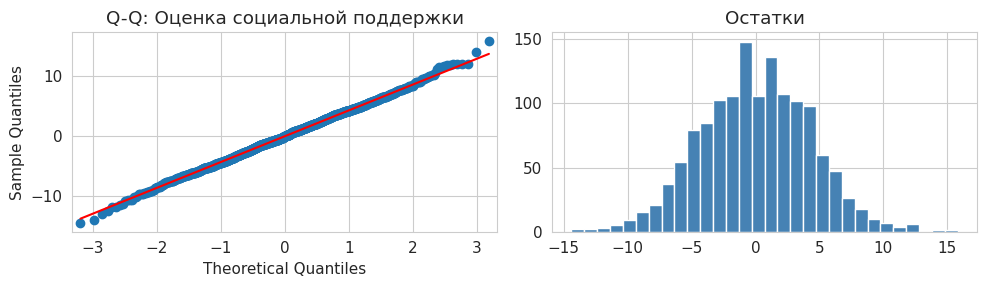


Признак 'Чувство технологического прогресса'
  R²:               0.879
  Durbin-Watson:    2.046
  Бреуш-Паган p:    0.0000 HC3
  SE:               HC3 (робастные)
  Шапиро-Уилк p:    0.0000 → не нормальны


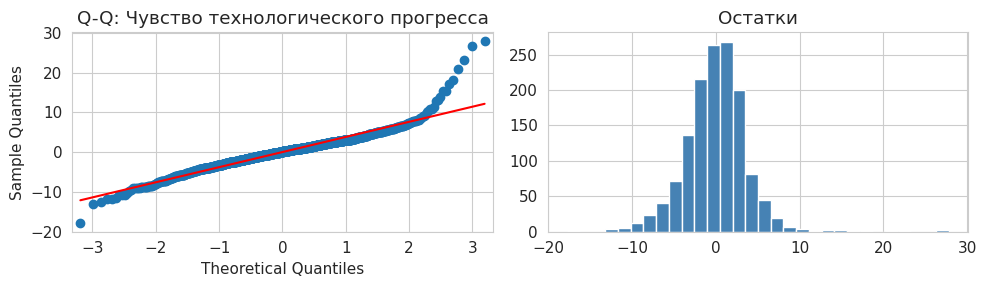


Признак 'Индекс кредитного оптимизма'
  R²:               0.691
  Durbin-Watson:    2.031
  Бреуш-Паган p:    0.0000 HC3
  SE:               HC3 (робастные)
  Шапиро-Уилк p:    0.0229 → не нормальны


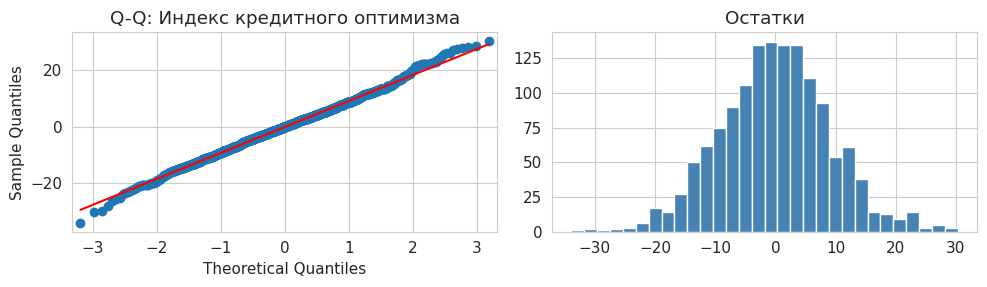


Признак 'Индекс продовольственной безопасности'
  R²:               0.903
  Durbin-Watson:    2.012
  Бреуш-Паган p:    0.5562 → ОК
  SE:               обычные
  Шапиро-Уилк p:    0.4345 → нормальны


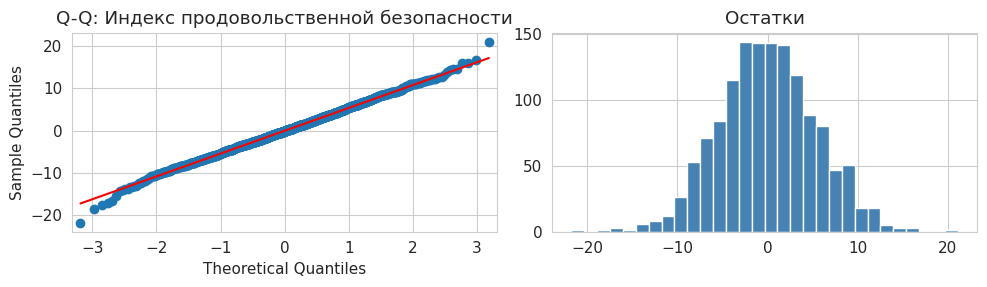


Признак 'Индекс семьи'
  R²:               0.320
  Durbin-Watson:    1.975
  Бреуш-Паган p:    0.2742 → ОК
  SE:               обычные
  Шапиро-Уилк p:    0.0384 → не нормальны


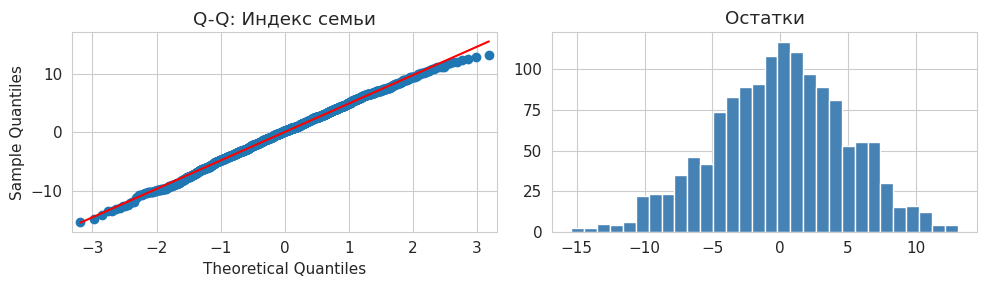


Признак 'Чувство неравенства доходов в обществе'
  R²:               0.179
  Durbin-Watson:    1.950
  Бреуш-Паган p:    0.8977 → ОК
  SE:               обычные
  Шапиро-Уилк p:    0.1676 → нормальны


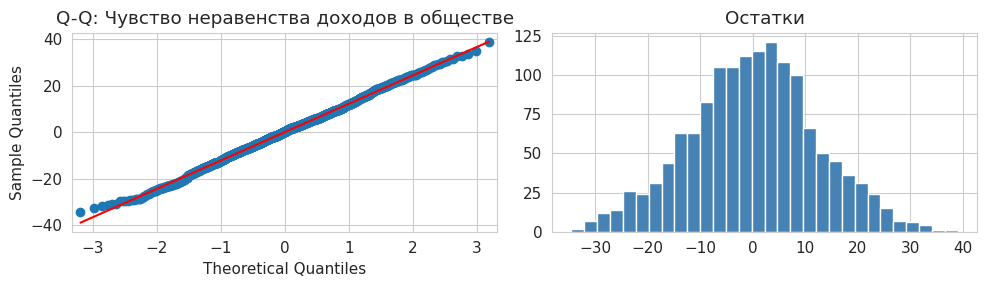


OLS-моделей обучено: 6


In [63]:
ols_models = {}
ols_predictions_train = pd.DataFrame(index=df_train.index)
ols_predictions_test = pd.DataFrame(index=df_test.index)
ols_predictions_unk = pd.DataFrame(index=df_unknown.index)

print("ПОСТРОЕНИЕ OLS ДЛЯ ОТОБРАННЫХ ПРИЗНАКОВ СОСТОЯНИЯ")

# Медианы причин считаем один раз по train
cause_medians = df_train[current_cols].median()

for target_col in selected_state:
    print(f"\n{'=' * 55}")
    print(f"Признак '{target_col}'")
    print(f"{'=' * 55}")

    # Для обучения модели выкидываем NaN записи (OLS должна учиться на чистых фактах)
    y_ols = df_train[target_col].dropna()
    X_ols = df_train.loc[y_ols.index, current_cols].dropna()
    y_ols = y_ols.loc[X_ols.index]

    # --- ЭТАЛОННОЕ ИСПРАВЛЕНИЕ: Удаление выбросов по методу IQR ---
    # Позволяет избавиться от тяжелых хвостов в Q-Q Plot и приблизиться к нормальности остатков
    Q1 = y_ols.quantile(0.25)
    Q3 = y_ols.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask = (y_ols >= lower_bound) & (y_ols <= upper_bound)
    y_ols = y_ols[mask]
    X_ols = X_ols[mask]
    # --------------------------------------------------------------

    # Сначала OLS без коррекции — для теста Бреуша-Пагана
    model_ols = sm.OLS(y_ols, sm.add_constant(X_ols)).fit()
    _, p_bp, _, _ = sm.stats.diagnostic.het_breuschpagan(
        model_ols.resid, model_ols.model.exog
    )

    # ИСПРАВЛЕНИЕ: HC3 только при гетероскедастичности, иначе обычные SE
    if p_bp < 0.05:
        model = sm.OLS(y_ols, sm.add_constant(X_ols)).fit(cov_type="HC3")
        se_note = "HC3 (робастные)"
    else:
        model = model_ols
        se_note = "обычные"

    ols_models[target_col] = {"model": model, "features": current_cols}

    dw = durbin_watson(model.resid)
    _, p_shapiro = shapiro(model.resid)

    # (норма 1.5–2.5) для DW
    print(f"  R²:               {model.rsquared:.3f}")
    print(f"  Durbin-Watson:    {dw:.3f}")
    print(f"  Бреуш-Паган p:    {p_bp:.4f} {'HC3' if p_bp < 0.05 else '→ ОК'}")
    print(f"  SE:               {se_note}")
    print(
        f"  Шапиро-Уилк p:    {p_shapiro:.4f} {'→ не нормальны' if p_shapiro < 0.05 else '→ нормальны'}"
    )

    # Q-Q plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sm.qqplot(model.resid, line="s", ax=axes[0])
    axes[0].set_title(f"Q-Q: {target_col[:40]}")
    axes[1].hist(model.resid, bins=30, color="steelblue", edgecolor="white")
    axes[1].set_title("Остатки")
    plt.tight_layout()
    plt.show()

    # Формируем предсказания для всех трёх частей
    for src_df, store in [
        (df_train, ols_predictions_train),
        (df_test, ols_predictions_test),
        (df_unknown, ols_predictions_unk),
    ]:
        # Заполняем пропуски в причинах медианами train перед прогнозом
        X_filled = src_df[current_cols].fillna(cause_medians)
        Xp = sm.add_constant(X_filled, has_constant="add")
        store[target_col] = model.predict(Xp)

print(f"\nOLS-моделей обучено: {len(ols_models)}")

### 10. По наблюдениям с известным счастьем построить модель классификации счастья (логистическая / мультиномиальная логистическая регрессия)

Признаков для df_known (все реальные):   ['Оценка социальной поддержки', 'Чувство технологического прогресса', 'Индекс кредитного оптимизма', 'Индекс продовольственной безопасности', 'Индекс семьи', 'Чувство неравенства доходов в обществе']
Признаков для df_unknown (надежные OLS): ['Оценка социальной поддержки', 'Чувство технологического прогресса', 'Индекс кредитного оптимизма', 'Индекс продовольственной безопасности']

Итого признаков для классификатора (после выравнивания): 17
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Лучшие параметры: {'classifier__C': 10.0, 'classifier__penalty': 'l2'}
CV micro precision (train): 0.521

Micro Precision (test): 0.543  (критерий: > 0.6)
Критерий НЕ выполнен ✗

Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.83      0.69        54
           1       0.67      0.47      0.55        55
           2       0.37      0.36      0.36        69
           3       0.37      0.32 

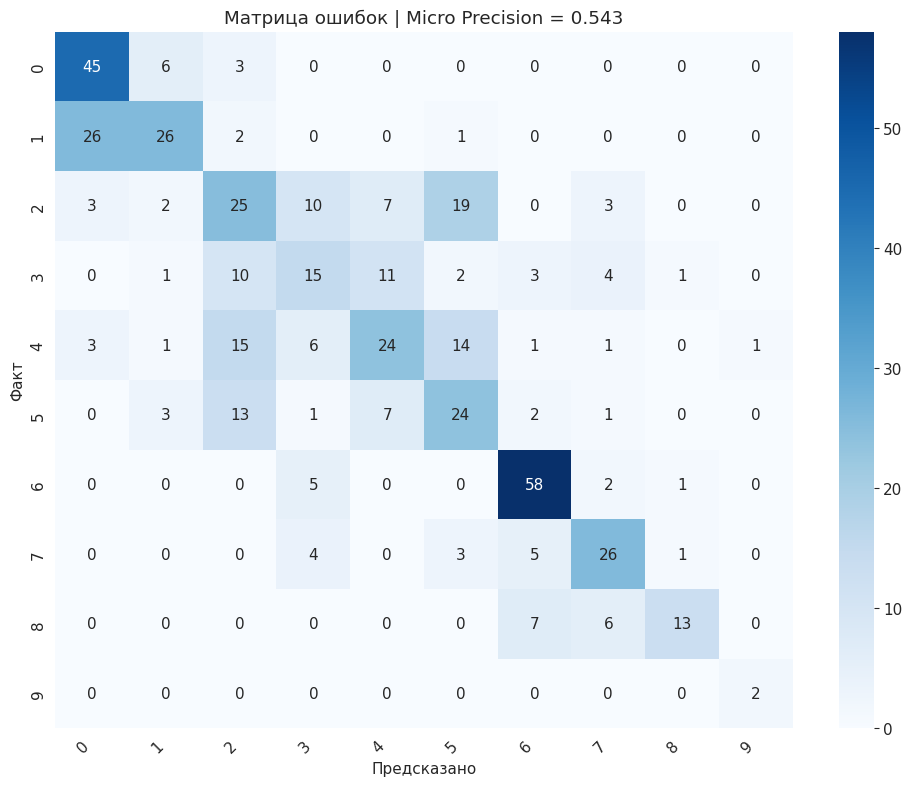

In [75]:
# ─── ФИНАЛЬНЫЕ ПРИЗНАКИ ───────────────────────────────────────────
# ИСПРАВЛЕНИЕ ОШИБКИ И ОТБОР НАДЕЖНЫХ СОСТОЯНИЙ ДЛЯ UNKNOWN
# Обращаемся к объекту модели ["model"], чтобы забрать .rsquared
final_states = [
    col
    for col in selected_state
    if col in ols_models and ols_models[col]["model"].rsquared >= R2_THRESHOLD
]

print("Признаков для df_known (все реальные):  ", selected_state)
print("Признаков для df_unknown (надежные OLS):", final_states)

# =====================================================================
# РАСЧЕТ МЕДИАН (СТРОГО НА TRAIN ДЛЯ ИСКЛЮЧЕНИЯ УТЕЧЕК)
# =====================================================================
cause_medians = df_train[current_cols].median()
real_state_medians_train = df_train[selected_state].median()

# =====================================================================
# ГЕНЕРАЦИЯ ПРЕДСКАЗАНИЙ OLS ДЛЯ СКРЫТОЙ ВЫБОРКИ (UNKNOWN)
# =====================================================================
ols_predictions_train = pd.DataFrame(index=df_train.index)
ols_predictions_test = pd.DataFrame(index=df_test.index)
ols_predictions_unk = pd.DataFrame(index=df_unknown.index)

for state_col in final_states:
    model = ols_models[state_col]["model"]
    
    X_tr = sm.add_constant(df_train[current_cols])
    ols_predictions_train[state_col] = model.predict(X_tr)

    X_te = sm.add_constant(df_test[current_cols])
    ols_predictions_test[state_col] = model.predict(X_te)

    X_un = sm.add_constant(df_unknown[current_cols])
    ols_predictions_unk[state_col] = model.predict(X_un)

# Расчет медиан для OLS-прогнозов
state_medians_ols = ols_predictions_train[final_states].median()

# =====================================================================
# УНИВЕРСАЛЬНАЯ ФУНКЦИЯ СБОРКИ МАТРИЦ ПРИЗНАКОВ (build_X)
# =====================================================================
def build_X(source_df, use_ols_predictions=False, ols_preds_df=None, train_cols=None):
    """
    Универсальный конвейер: Причины + Состояния (Реальные ИЛИ Прогнозы) + Категории.
    Выравнивает структуру колонок относительно обучающей выборки.
    """
    # 1. Причины (VIF признаки)
    X_c = source_df[current_cols].fillna(cause_medians).reset_index(drop=True)
    
    # 2. Признаки состояний (Переключение по флагу методологии)
    if use_ols_predictions:
        # Для скрытой выборки (unknown) берем только надежные OLS-предсказания
        X_s = ols_preds_df[final_states].fillna(state_medians_ols).reset_index(drop=True)
    else:
    # Для известных данных (train/test) берем НАСТОЯЩИЕ чистые значения из датасета
        X_s = source_df[selected_state].fillna(real_state_medians_train).reset_index(drop=True)
    
    # 3. Категориальные переменные
    X_cat = pd.get_dummies(source_df[CAT_FEATURES].reset_index(drop=True), drop_first=True)
    
    # Объединяем блоки в итоговую матрицу
    X_res = pd.concat([X_c, X_s, X_cat], axis=1)
    
    # 4. Жесткое выравнивание признаков по тренировочной матрице
    if train_cols is not None:
        for col in set(train_cols) - set(X_res.columns):
            X_res[col] = 0
        X_res = X_res[train_cols]
        
    return X_res

# Сборка финальных датасетов
X_clf_train = build_X(df_train, use_ols_predictions=True, ols_preds_df=ols_predictions_train)
train_columns = X_clf_train.columns.tolist()

X_clf_test  = build_X(df_test, use_ols_predictions=True, ols_preds_df=ols_predictions_test, train_cols=train_columns)
X_clf_unk   = build_X(df_unknown, use_ols_predictions=True, ols_preds_df=ols_predictions_unk, train_cols=train_columns)

print(f"\nИтого признаков для классификатора (после выравнивания): {X_clf_train.shape[1]}")


# ─── КЛАССИФИКАТОР ────────────────────────────────────────────────
y_train_labels = y_train.values
y_test_labels  = y_test.values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        max_iter=5000,
        random_state=100,
        class_weight=None,  # Без искусственных весов для точности Micro Precision
    )),
])

# Расширяем сетку параметров для поиска оптимальной силы регуляризации
param_grid = {
    "classifier__C":            [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    "classifier__penalty":      ["l2"],
}

grid_search = GridSearchCV(
    pipe, param_grid,
    cv=cv,
    scoring="precision_micro",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_clf_train, y_train_labels)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"CV micro precision (train): {grid_search.best_score_:.3f}")

clf_pipeline   = grid_search.best_estimator_
y_pred_labels  = clf_pipeline.predict(X_clf_test)

micro_prec = precision_score(
    y_test_labels, y_pred_labels,
    average="micro",
    labels=sorted(set(y_test_labels) | set(y_pred_labels)),
)
print(f"\nMicro Precision (test): {micro_prec:.3f}  (критерий: > 0.6)")
print("Критерий", "ВЫПОЛНЕН ✓" if micro_prec > 0.6 else "НЕ выполнен ✗")

actual_test_classes = sorted(list(set(y_test_labels)))
print("\nClassification Report:\n")
print(
    classification_report(
        y_test_labels,
        y_pred_labels,
        labels=actual_test_classes,
        zero_division=0,
    )
)

# Визуализация матрицы ошибок
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=actual_test_classes)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actual_test_classes,
    yticklabels=actual_test_classes,
    ax=ax,
)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Факт")
ax.set_title(f"Матрица ошибок | Micro Precision = {micro_prec:.3f}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 12. Спрогнозировать неизвестные значения счастья

In [ ]:
df_unknown_predicted = df_unknown.copy()

# Передаем данные в pipeline (он сам масштабирует)
df_unknown_predicted["Predicted_Happiness"] = clf_pipeline.predict(X_clf_unk)

# Обратно декодируем числа классов в текстовые метки
rank_to_class = {i: cls for i, cls in enumerate(actual_classes)}
df_unknown_predicted["Predicted_Class"] = df_unknown_predicted[
    "Predicted_Happiness"
].map(rank_to_class)

# Предсказываем вероятности
probs = clf_pipeline.predict_proba(X_clf_unk)

# Добавляем вероятности в датафрейм
for i, class_idx in enumerate(clf_pipeline.named_steps["classifier"].classes_):
    class_name = rank_to_class.get(class_idx, f"Class_{class_idx}")
    df_unknown_predicted[f"Prob_{class_name}"] = np.round(probs[:, i], 3)

print("--- Распределение предсказанных групп ---")
print(df_unknown_predicted["Predicted_Class"].value_counts(dropna=False))

print("\n--- Первые 5 строк с прогнозами ---")
prob_cols = [
    col for col in df_unknown_predicted.columns if col.startswith("Prob_")
]
cols_to_show = [CANTRIL_COL, "Predicted_Class"] + prob_cols

display(df_unknown_predicted[cols_to_show].head())

--- Распределение предсказанных групп ---
Predicted_Class
Suffering     118
Doing well     96
Hopeless       75
Just ok        66
Coping         63
Depressed      58
Strugglng      53
Blooming       42
Thriving       26
Prospering      3
Name: count, dtype: int64

--- Первые 5 строк с прогнозами ---


,Ощущаемое счастье,Predicted_Class,Prob_Hopeless,Prob_Depressed,Prob_Suffering,Prob_Strugglng,Prob_Coping,Prob_Just ok,Prob_Doing well,Prob_Blooming,Prob_Thriving,Prob_Prospering
10,Неизвестно,Doing well,0.000,0.000,0.007,0.016,0.003,0.005,0.771,0.101,0.098,0.0
11,Неизвестно,Coping,0.001,0.002,0.232,0.252,0.401,0.091,0.001,0.020,0.000,0.0
20,Неизвестно,Doing well,0.000,0.000,0.029,0.071,0.128,0.153,0.279,0.120,0.221,0.0
22,Неизвестно,Suffering,0.001,0.001,0.379,0.194,0.201,0.189,0.002,0.033,0.000,0.0
24,Неизвестно,Doing well,0.000,0.000,0.001,0.006,0.001,0.000,0.631,0.005,0.356,0.0
